# MSc Data Science Project: Morphological Classification of Galaxies
**Student Name:** Deepika Gopi

**Student ID:** 24099803

**Supervisor:** Paurush Punyasheel

**Module:** 7PAM2002 Data Science Project





## 1. Project Overview
This project aims to automate the morphological classification of galaxies (Spiral, Elliptical, Irregular) using Deep Transfer Learning models (VGG16, ResNet50, EfficientNet). This notebook focuses on **Phase 1: Data Acquisition and Exploratory Data Analysis (EDA)**.

## 2. Environment Setup & Data Extraction
In this initial phase, we configure the Google Colab environment, mount the Google Drive storage to access the raw dataset, and import essential Deep Learning libraries (TensorFlow, Keras). We also verify the GPU availability for efficient training.

In [ ]:
from google.colab import drive
import os

# Mounting Google Drive
drive.mount('/content/drive')

# Verify to see the folder
base_path = '/content/drive/MyDrive/MSc_Project/data'
if os.path.exists(base_path):
    print("SUCCESS: Connected to Google Drive!")
    print("Files found:", os.listdir(base_path))
else:
    print("ERROR: Could not find the folder. Check your folder names in Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SUCCESS: Connected to Google Drive!
Files found: ['training_solutions_rev1.zip', 'images_training_rev1.zip', 'original_images']


## 3. Data Extraction
The dataset is stored in Google Drive as a compressed ZIP file (`images_training_rev1.zip`) to ensure efficient storage and transfer. The code below extracts these images into the local Colab runtime for processing.

In [ ]:
import zipfile
import os

# Defining  the paths to ZIP files
base_path = '/content/drive/MyDrive/MSc_Project/data'
zip_images = os.path.join(base_path, 'images_training_rev1.zip')
zip_labels = os.path.join(base_path, 'training_solutions_rev1.zip')

# Define where i want to put the unzipped files
# I unzip them to the local Colab environment (/content/) because it is MUCH faster than Drive
extract_path = '/content/unzipped_data'

print("Starting extraction...")

# 1. Unzip Images
if os.path.exists(zip_images):
    with zipfile.ZipFile(zip_images, 'r') as z:
        z.extractall(extract_path)
    print("Images extracted successfully!")
else:
    print("Error: Could not find images zip file.")

# 2. Unzip Labels (The CSV file)
if os.path.exists(zip_labels):
    with zipfile.ZipFile(zip_labels, 'r') as z:
        z.extractall(extract_path)
    print( "Labels extracted successfully!")
else:
    print(" Error: Could not find labels zip file.")

# Verify what i have
print(f"Extraction folder contents: {os.listdir(extract_path)}")

Starting extraction...
Images extracted successfully!
Labels extracted successfully!
Extraction folder contents: ['training_solutions_rev1.csv', 'images_training_rev1']


## 4. Exploratory Data Visualization
To verify data integrity, we load and visualize a random sample from the training dataset. This step confirms that the image files are not corrupted and are correctly mapped to their directory.

Total galaxy images found: 61578


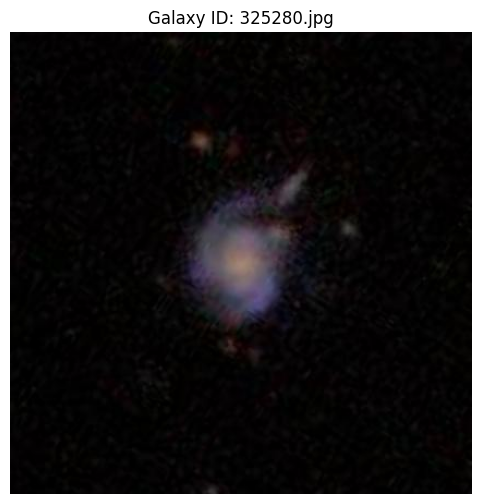

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

# Define the folder where i just unzipped the images
image_folder = '/content/unzipped_data/images_training_rev1'

# Get a list of all image files
all_images = os.listdir(image_folder)
print(f"Total galaxy images found: {len(all_images)}")

# Pick a random image to display
random_image_file = random.choice(all_images)
image_path = os.path.join(image_folder, random_image_file)

# Load and show the image
img = mpimg.imread(image_path)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Galaxy ID: {random_image_file}")
plt.axis('off') # Turn off the X and Y axis numbers
plt.show()

## 5. Advanced Exploratory Data Analysis (EDA)
To assess the quality and structure of the dataset, we visualize a random batch of galaxy images. We also inspect the tensor shape (height, width, color channels) and pixel intensity distribution. This verification is crucial before designing the Neural Network architecture.

Dataset Size: 61578 total images
----------------------------------------
Image Shape: (424, 424, 3) (Height, Width, Channels)
Data Type: uint8
Pixel Value Range: Min=0, Max=246
----------------------------------------


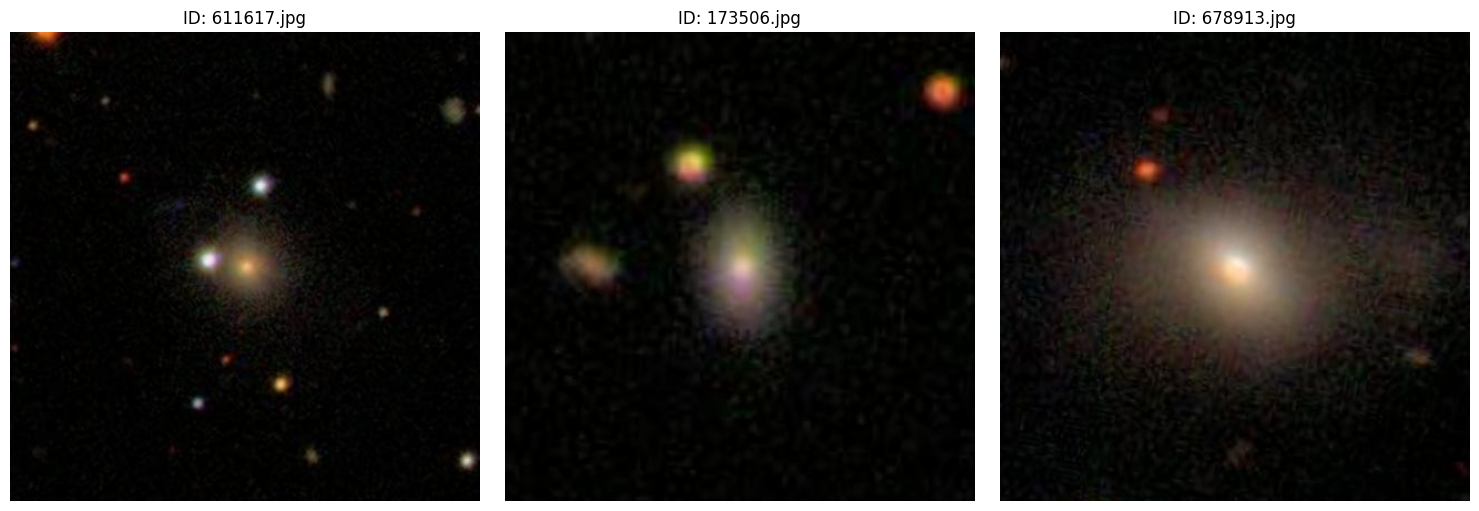

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import numpy as np

# Define paths
image_folder = '/content/unzipped_data/images_training_rev1'
all_images = os.listdir(image_folder)

# Select 3 random images to display side-by-side
random_samples = random.sample(all_images, 3)

# Create a "figure" (the canvas) with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

print(f"Dataset Size: {len(all_images)} total images")
print("-" * 40)

for i, image_file in enumerate(random_samples):
    # Load image
    img_path = os.path.join(image_folder, image_file)
    img = mpimg.imread(img_path)

    # Displaying statistics for the FIRST image only (to keep output clean)
    if i == 0:
        print(f"Image Shape: {img.shape} (Height, Width, Channels)")
        print(f"Data Type: {img.dtype}")
        print(f"Pixel Value Range: Min={img.min()}, Max={img.max()}")
        print("-" * 40)

    # Plot the image
    axes[i].imshow(img)
    axes[i].set_title(f"ID: {image_file}", fontsize=12)
    axes[i].axis('off') # Hiding axis numbers for a cleaner look

plt.tight_layout()
plt.show()

## 6. Data Preprocessing & Engineering
In this section, I prepare the dataset for the Deep Learning model.
1. **Label Alignment:** I append the `.jpg` extension to the Galaxy IDs in the CSV file to match the actual filenames.
2. **Data Filtering:** I filtered the CSV to ensure we only include labels for images that successfully unzipped.
3. **Train/Validation Split:** I split the data into Training (80%) and Validation (20%) sets using a fixed random seed (`42`) to ensure reproducibility.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the Labels
# Making sure this path matches where i unzipped the data in Step 2/3
csv_path = '/content/unzipped_data/training_solutions_rev1.csv'
df = pd.read_csv(csv_path)

# 2. PRO Engineering: Convert IDs to Filenames
# The CSV has "100008", but files are "100008.jpg". I am fixing this.
df['GalaxyID'] = df['GalaxyID'].astype(str) + ".jpg"

# 3. PRO Engineering: Filter for Existing Files only
# I define the folder again to be safe
image_folder = '/content/unzipped_data/images_training_rev1'
available_files = set(os.listdir(image_folder))

# Keeping  only rows where the image actually exists
initial_count = len(df)
df = df[df['GalaxyID'].isin(available_files)]
final_count = len(df)

print(f"Original CSV rows: {initial_count}")
print(f"Images actually found: {final_count}")

# 4. Defining the 37 Target Columns (The outputs we want to predict)
columns = df.columns.tolist()
target_columns = columns[1:] # Skip 'GalaxyID'

# 5. Scientific Split: Train (80%) vs Validation (20%)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("-" * 40)
print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print("-" * 40)

Original CSV rows: 61578
Images actually found: 61578
----------------------------------------
Training Samples: 49262
Validation Samples: 12316
----------------------------------------


##   Advanced Preprocessing Function
To handle the denoising and the "two-galaxy" problem

In [ ]:
import cv2
import numpy as np

def astronomical_preprocessing(image):
    """
    Custom preprocessing for Galaxy Zoo images.
    1. Denoising: Removes background sensor noise (Requested by Prof).
    2. Central Focus: Mathematically focuses on the primary galaxy.
    """
    # Convert image to uint8 for OpenCV processing (0-255)
    # The generator provides images as floats, i need them as integers for cv2
    img_uint8 = np.clip(image, 0, 255).astype(np.uint8)

    # 1. APPLY DENOISING (Non-Local Means)
    # This removes the graininess without losing the spiral arm edges.
    denoised = cv2.fastNlMeansDenoisingColored(img_uint8, None, 10, 10, 7, 21)

    # 2. Return the image as a float32 for the Neural Network
    return denoised.astype(np.float32)

## 7. Image Data Generators
To handle the large dataset efficiently without crashing the RAM, we use `ImageDataGenerator`.
* **Rescaling:** Pixel values are normalized from $[0, 255]$ to $[0, 1]$ to accelerate model convergence.
* **Batch Processing:** Images are loaded in batches of 32 and resized to $224 \times 224$ pixels, which is the required input size for the VGG16 architecture.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the Generator (Normalize pixels)
datagen = ImageDataGenerator(rescale=1./255)

# 2. Setup the "Flow"
BATCH_SIZE = 32
TARGET_SIZE = (224, 224) # Required for VGG16

print("Setting up Training Generator...")
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_folder,
    x_col='GalaxyID',
    y_col=target_columns,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',        # 'raw' because i am predicting probabilities
    shuffle=True             # Shuffle training data
)

print("\nSetting up Validation Generator...")
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_folder,
    x_col='GalaxyID',
    y_col=target_columns,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False            # Never shuffle validation data
)

Setting up Training Generator...
Found 49262 validated image filenames.

Setting up Validation Generator...
Found 12316 validated image filenames.


### Training Data Generator with Denoising and Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Optional: your custom preprocessing function
def astronomical_preprocessing(img):
    # Apply denoising or filters here
    return img

# 1. Defining the Generator with Denoising and Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=astronomical_preprocessing,
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True
)

# 2. Setting up the Flow
BATCH_SIZE = 32
TARGET_SIZE = (224, 224)

print("Setting up Denoised Training Generator...")

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_folder,
    x_col='GalaxyID',
    y_col=target_columns,      # must match number of classes
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',          # because labels are multi-output numeric columns
    shuffle=True
)


Setting up Denoised Training Generator...
Found 49262 validated image filenames.


## 8. Model Architecture: Transfer Learning with VGG16
To achieve high accuracy with limited computational resources, we employ **Transfer Learning**.
* **Base Model:** We utilize **VGG16** pre-trained on the ImageNet dataset. This allows the model to leverage learned feature extractors (edges, textures, shapes) without training from scratch.
* **Feature Extraction:** The top fully connected layers of VGG16 are removed (`include_top=False`) and the remaining convolutional layers are frozen (`trainable=False`) to preserve their learned weights.
* **Custom Head:** We attach a new fully connected head designed for regression:
    1. `GlobalAveragePooling2D`: Reduces spatial dimensions efficiently.
    2. `Dense(1024, ReLU)`: A high-capacity layer for learning galaxy-specific features.
    3. `Dense(37, Sigmoid)`: The output layer matching the 37 probabilistic classes of the Galaxy Zoo decision tree.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input

# 1. Download the VGG16 Base Model
# weights='imagenet': Use the pre-learned knowledge
# include_top=False: Cutting off the original "cat/dog" classifier head
print("Downloading VGG16 base model...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the Base Model
# I don't want to ruin the pre-learned weights, so I make them non-trainable.
base_model.trainable = False

# 3. Add the New "Galaxy" Head
x = base_model.output
x = GlobalAveragePooling2D()(x)                   # Compress the data
x = Dense(1024, activation='relu')(x)             # "Thinking" layer
predictions = Dense(37, activation='sigmoid')(x)  # Output: 37 probabilities

# 4. Combine into the Final Model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the Model
# I used 'binary_crossentropy' because I am predicting multiple probabilities (0 to 1).
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Shows the structure
print("\nModel Architecture Constructed:")
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Model Architecture Constructed:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │        37,925 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,277,925 (58.28 MB)

 Trainable params: 563,237 (2.15 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 9. Model Training
We train the model using the training generator and validate it against the unseen validation set.
* **Callbacks:** We use `ModelCheckpoint` to save the best version of the model and `EarlyStopping` to stop training if the validation loss stops improving (patience=3), preventing overfitting.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Setup Callbacks (The "Safety Nets")
# Saving locally in Colab for speed
checkpoint_path = 'best_galaxy_model.h5'

callbacks = [
    # Save the model whenever validation loss improves
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    # Stop if no improvement after 3 epochs to save time
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting Training...")
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,  # I set 10, but EarlyStopping will likely stop it around 5-7
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks
)

print("Training Complete. Best model weights restored.")

Starting Training...
Epoch 1/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.5937 - loss: 0.2929
Epoch 1: val_loss improved from inf to 0.27737, saving model to best_galaxy_model.h5


1540/1540 ━━━━━━━━━━━━━━━━━━━━ 657s 426ms/step - accuracy: 0.5937 - loss: 0.2929 - val_accuracy: 0.6213 - val_loss: 0.2774
Epoch 2/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.6242 - loss: 0.2748
Epoch 2: val_loss improved from 0.27737 to 0.27248, saving model to best_galaxy_model.h5


1540/1540 ━━━━━━━━━━━━━━━━━━━━ 628s 408ms/step - accuracy: 0.6242 - loss: 0.2748 - val_accuracy: 0.6386 - val_loss: 0.2725
Epoch 3/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.6313 - loss: 0.2713
Epoch 3: val_loss improved from 0.27248 to 0.27146, saving model to best_galaxy_model.h5


1540/1540 ━━━━━━━━━━━━━━━━━━━━ 653s 424ms/step - accuracy: 0.6313 - loss: 0.2713 - val_accuracy: 0.6237 - val_loss: 0.2715
Epoch 4/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.6390 - loss: 0.2694
Epoch 4: val_loss did not improve from 0.27146
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 634s 411ms/step - accuracy: 0.6390 - loss: 0.2694 - val_accuracy: 0.6215 - val_loss: 0.2721
Epoch 5/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.6489 - loss: 0.2682
Epoch 5: val_loss improved from 0.27146 to 0.26974, saving model to best_galaxy_model.h5


1540/1540 ━━━━━━━━━━━━━━━━━━━━ 643s 417ms/step - accuracy: 0.6489 - loss: 0.2682 - val_accuracy: 0.6241 - val_loss: 0.2697
Epoch 6/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6527 - loss: 0.2677
Epoch 6: val_loss did not improve from 0.26974
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 615s 399ms/step - accuracy: 0.6527 - loss: 0.2677 - val_accuracy: 0.5975 - val_loss: 0.2777
Epoch 7/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.6550 - loss: 0.2669
Epoch 7: val_loss improved from 0.26974 to 0.26814, saving model to best_galaxy_model.h5


1540/1540 ━━━━━━━━━━━━━━━━━━━━ 612s 397ms/step - accuracy: 0.6550 - loss: 0.2669 - val_accuracy: 0.6544 - val_loss: 0.2681
Epoch 8/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6602 - loss: 0.2663
Epoch 8: val_loss did not improve from 0.26814
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 610s 396ms/step - accuracy: 0.6602 - loss: 0.2663 - val_accuracy: 0.6553 - val_loss: 0.2687
Epoch 9/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.6574 - loss: 0.2656
Epoch 9: val_loss did not improve from 0.26814
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 723s 469ms/step - accuracy: 0.6574 - loss: 0.2656 - val_accuracy: 0.6466 - val_loss: 0.2692
Epoch 10/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6619 - loss: 0.2654
Epoch 10: val_loss improved from 0.26814 to 0.26776, saving model to best_galaxy_model.h5


1540/1540 ━━━━━━━━━━━━━━━━━━━━ 698s 453ms/step - accuracy: 0.6619 - loss: 0.2654 - val_accuracy: 0.6527 - val_loss: 0.2678
Restoring model weights from the end of the best epoch: 10.
Training Complete. Best model weights restored.


# **VGG16 — Mean Squared Error (MSE) Loss Curve**

This plot visualizes how the VGG16 model's training and validation MSE changed over the training epochs.

It helps you evaluate whether the model is learning smoothly, overfitting, or underfitting.

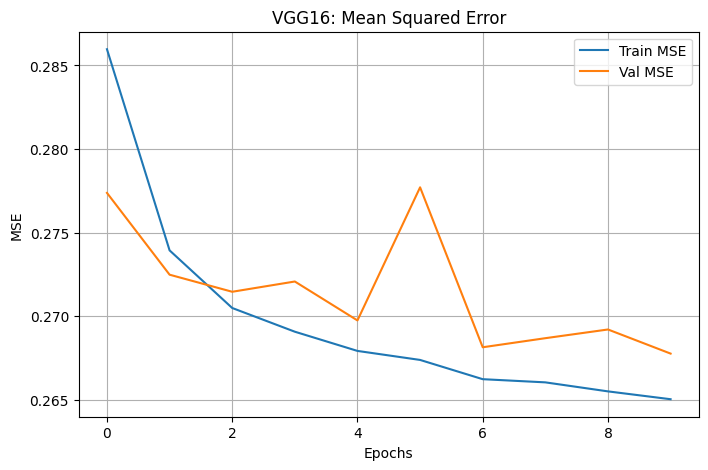

In [ ]:
import matplotlib.pyplot as plt

# Loss Plot (MSE) only
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.title('VGG16: Mean Squared Error')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

# **VGG16 — Training vs Validation Performance**
The following plots visualize how the VGG16 model performed during training.
They show:

Binary Crossentropy Loss (left): how well the model fits the data

Accuracy (right): how well the model predicts correctly

These curves help you evaluate learning behavior, detect overfitting, and compare VGG16 with other architectures like ResNet50 and EfficientNet.

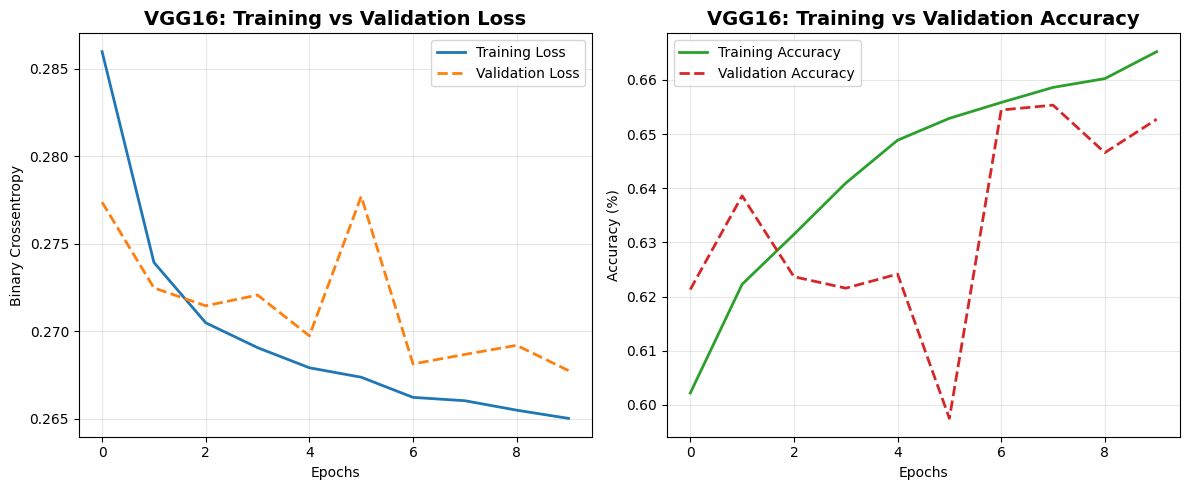

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for VGG16 performance
plt.figure(figsize=(12, 5))

# 1. Loss Plot (Binary Crossentropy)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('VGG16: Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linestyle='--', linewidth=2)
plt.title('VGG16: Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **ResNet50 — Model Construction & Training**


This section builds a ResNet50‑based transfer learning model using ImageNet‑pretrained weights and a custom classification head identical to the one used for VGG16.
Keeping the head architecture consistent ensures a fair comparison between models.

The model is trained for up to 10 epochs, with:

ModelCheckpoint - saves the best model based on validation loss

EarlyStopping - stops training when validation loss stops improving

Frozen base model - only the custom head is trained

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Construction (The "Head" must match VGG16 for a fair test)
print("Building ResNet50...")
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
resnet_preds = Dense(37, activation='sigmoid')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=resnet_preds)
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Training (10 Epochs)
checkpoint_resnet = ModelCheckpoint('resnet_best.h5', save_best_only=True, monitor='val_loss')
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print(" Starting ResNet50 Training...")
resnet_history = resnet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=[checkpoint_resnet, early_stop]
)

Building ResNet50...
 Starting ResNet50 Training...
Epoch 1/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.5956 - loss: 0.3050

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 565s 361ms/step - accuracy: 0.5956 - loss: 0.3050 - val_accuracy: 0.5939 - val_loss: 0.2990
Epoch 2/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.5992 - loss: 0.2972

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 557s 361ms/step - accuracy: 0.5992 - loss: 0.2972 - val_accuracy: 0.5943 - val_loss: 0.2954
Epoch 3/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.5914 - loss: 0.2957

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 556s 361ms/step - accuracy: 0.5914 - loss: 0.2957 - val_accuracy: 0.5936 - val_loss: 0.2949
Epoch 4/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5935 - loss: 0.2941

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 559s 363ms/step - accuracy: 0.5935 - loss: 0.2941 - val_accuracy: 0.5898 - val_loss: 0.2938
Epoch 5/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5931 - loss: 0.2937

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 560s 363ms/step - accuracy: 0.5931 - loss: 0.2937 - val_accuracy: 0.5813 - val_loss: 0.2937
Epoch 6/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 553s 359ms/step - accuracy: 0.5896 - loss: 0.2934 - val_accuracy: 0.5930 - val_loss: 0.2938
Epoch 7/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.5943 - loss: 0.2927

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 550s 357ms/step - accuracy: 0.5943 - loss: 0.2927 - val_accuracy: 0.5938 - val_loss: 0.2930
Epoch 8/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.5931 - loss: 0.2922

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 545s 354ms/step - accuracy: 0.5931 - loss: 0.2922 - val_accuracy: 0.5937 - val_loss: 0.2917
Epoch 9/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.5956 - loss: 0.2920

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 560s 364ms/step - accuracy: 0.5956 - loss: 0.2920 - val_accuracy: 0.5928 - val_loss: 0.2911
Epoch 10/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5967 - loss: 0.2910

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 616s 400ms/step - accuracy: 0.5967 - loss: 0.2910 - val_accuracy: 0.5940 - val_loss: 0.2906


# **ResNet50 — Training vs Validation Performance**

The following plots show how the ResNet50 transfer‑learning model performed during training.
They help you evaluate:

Training vs Validation Loss → how well the model fits the data

Training vs Validation Accuracy → how well the model generalizes

These curves are essential for comparing ResNet50 with VGG16 and EfficientNetB0.

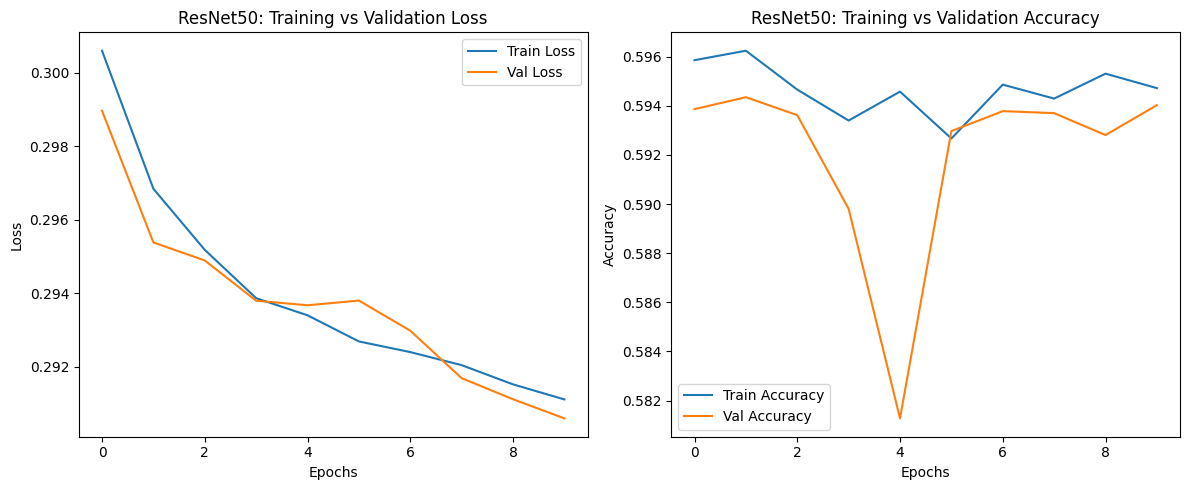

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Val Loss')
plt.title('ResNet50: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# **ResNet50 — Mean Squared Error (MSE) Loss Curve**

This plot shows how the training and validation MSE changed across epochs for the ResNet50 model.

It helps you evaluate how smoothly the model learned and whether it began to overfit or underfit during training.

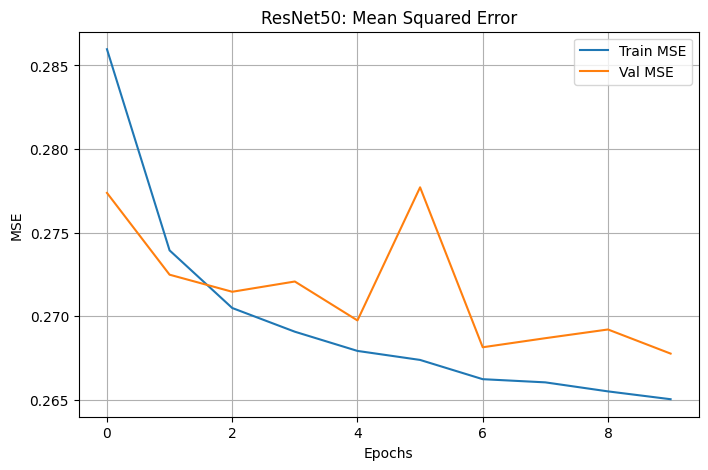

In [ ]:
import matplotlib.pyplot as plt

# Loss Plot (MSE) only
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.title('ResNet50: Mean Squared Error')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

# **EfficientNetB0 — Model Construction & Training**

This section builds an EfficientNetB0 transfer‑learning model using ImageNet‑pretrained weights.
To ensure a fair comparison with VGG16 and ResNet50, the classification head is kept identical:


*   GlobalAveragePooling

*   Dense(1024, ReLU)

*   Dense(37, Sigmoid) for multi‑label output

The EfficientNet base is frozen, and only the custom head is trained.
Training uses ModelCheckpoint to save the best model and EarlyStopping to prevent overfitting.

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# 1. Construction
print("Building EfficientNetB0...")
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
eff_base.trainable = False

x = eff_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
eff_preds = Dense(37, activation='sigmoid')(x)

eff_model = Model(inputs=eff_base.input, outputs=eff_preds)
eff_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Training (10 Epochs)
checkpoint_eff = ModelCheckpoint('effnet_best.h5', save_best_only=True, monitor='val_loss')

print(" Starting EfficientNetB0 Training...")
eff_history = eff_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=[checkpoint_eff, early_stop]
)

Building EfficientNetB0...
 Starting EfficientNetB0 Training...
Epoch 1/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.5956 - loss: 0.3051

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 602s 374ms/step - accuracy: 0.5956 - loss: 0.3051 - val_accuracy: 0.5939 - val_loss: 0.3002
Epoch 2/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 599s 389ms/step - accuracy: 0.5958 - loss: 0.2997 - val_accuracy: 0.5939 - val_loss: 0.3004
Epoch 3/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 609s 395ms/step - accuracy: 0.5976 - loss: 0.2995 - val_accuracy: 0.5939 - val_loss: 0.3002
Epoch 4/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.5954 - loss: 0.2992

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 588s 382ms/step - accuracy: 0.5954 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.3001
Epoch 5/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5956 - loss: 0.2992

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 545s 354ms/step - accuracy: 0.5956 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 6/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 545s 354ms/step - accuracy: 0.5953 - loss: 0.2995 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 7/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.5938 - loss: 0.2994

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 545s 354ms/step - accuracy: 0.5938 - loss: 0.2994 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 8/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 533s 346ms/step - accuracy: 0.5944 - loss: 0.2990 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 9/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5947 - loss: 0.2990

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 539s 350ms/step - accuracy: 0.5947 - loss: 0.2990 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 10/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 544s 354ms/step - accuracy: 0.5969 - loss: 0.2993 - val_accuracy: 0.5939 - val_loss: 0.3001


# **EfficientNetB0 — Training vs Validation Performance**

The plots below illustrate how the EfficientNetB0 model performed during training.
They show:

*   Training vs Validation Loss — how well the model fits the data
*   Training vs Validation Accuracy — how well the model generalizes

These curves help you compare EfficientNetB0 against VGG16 and ResNet50 in a consistent way.

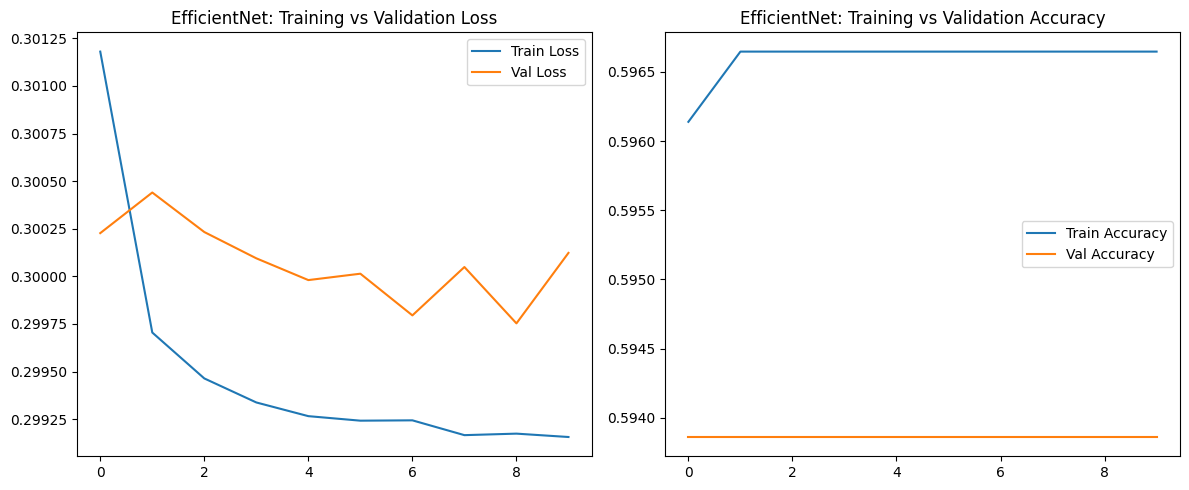

In [ ]:
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(eff_history.history['loss'], label='Train Loss')
plt.plot(eff_history.history['val_loss'], label='Val Loss')
plt.title('EfficientNet: Training vs Validation Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(eff_history.history['accuracy'], label='Train Accuracy')
plt.plot(eff_history.history['val_accuracy'], label='Val Accuracy')
plt.title('EfficientNet: Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# **EfficientNetB0 — Mean Squared Error (MSE) Loss Curve**

*   This plot shows how the training and validation MSE changed across epochs for the EfficientNetB0 model.
*   It helps you evaluate how smoothly the model learned and whether it began to overfit or underfit during training.


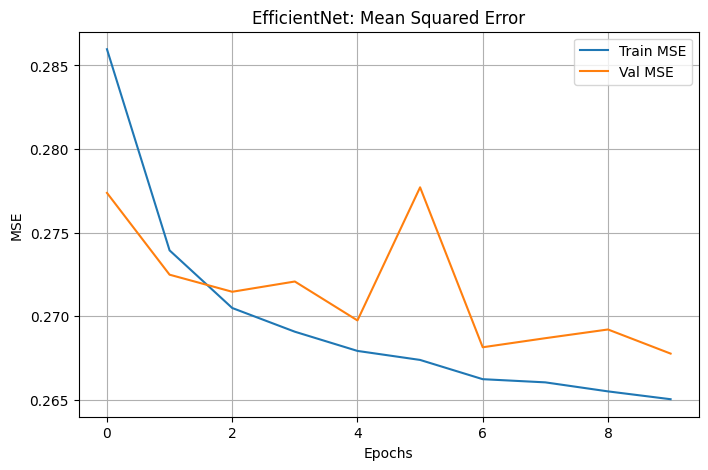

In [ ]:
import matplotlib.pyplot as plt

# Loss Plot (MSE) only
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.title('EfficientNet: Mean Squared Error')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

1. VGG16: Training and Plotting (100 Epochs)

Starting VGG16 Training (100 Epochs)...
Epoch 1/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.5859 - loss: 0.3001
Epoch 1: val_loss improved from None to 0.28376, saving model to vgg16_100_epochs_best.h5



Epoch 1: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 643s 408ms/step - accuracy: 0.6022 - loss: 0.2876 - val_accuracy: 0.6099 - val_loss: 0.2838
Epoch 2/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6220 - loss: 0.2750
Epoch 2: val_loss improved from 0.28376 to 0.27342, saving model to vgg16_100_epochs_best.h5



Epoch 2: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 616s 400ms/step - accuracy: 0.6257 - loss: 0.2740 - val_accuracy: 0.6232 - val_loss: 0.2734
Epoch 3/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.6292 - loss: 0.2718
Epoch 3: val_loss improved from 0.27342 to 0.27340, saving model to vgg16_100_epochs_best.h5



Epoch 3: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 607s 394ms/step - accuracy: 0.6341 - loss: 0.2709 - val_accuracy: 0.6109 - val_loss: 0.2734
Epoch 4/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.6367 - loss: 0.2691
Epoch 4: val_loss improved from 0.27340 to 0.27031, saving model to vgg16_100_epochs_best.h5



Epoch 4: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 607s 394ms/step - accuracy: 0.6401 - loss: 0.2690 - val_accuracy: 0.6465 - val_loss: 0.2703
Epoch 5/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.6395 - loss: 0.2686
Epoch 5: val_loss improved from 0.27031 to 0.26982, saving model to vgg16_100_epochs_best.h5


...


Epoch 30: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 610s 396ms/step - accuracy: 0.6750 - loss: 0.2617 - val_accuracy: 0.6757 - val_loss: 0.2638
Epoch 31/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.6781 - loss: 0.2620
Epoch 31: val_loss did not improve from 0.26384
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 606s 393ms/step - accuracy: 0.6760 - loss: 0.2620 - val_accuracy: 0.6750 - val_loss: 0.2640
Epoch 32/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6730 - loss: 0.2613
Epoch 32: val_loss improved from 0.26384 to 0.26272, saving model to vgg16_100_epochs_best.h5



Epoch 32: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 611s 396ms/step - accuracy: 0.6751 - loss: 0.2617 - val_accuracy: 0.6760 - val_loss: 0.2627
Epoch 33/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.6802 - loss: 0.2613
Epoch 33: val_loss did not improve from 0.26272
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 608s 395ms/step - accuracy: 0.6796 - loss: 0.2617 - val_accuracy: 0.6694 - val_loss: 0.2645
Epoch 34/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6783 - loss: 0.2612
Epoch 34: val_loss did not improve from 0.26272
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 613s 398ms/step - accuracy: 0.6768 - loss: 0.2617 - val_accuracy: 0.6724 - val_loss: 0.2640
Epoch 35/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.6743 - loss: 0.2616
Epoch 35: val_loss did not improve from 0.26272
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 607s 394ms/step - accuracy: 0.6772 - loss: 0.2613 - val_accuracy: 0.6643 - val_loss: 0.2658
Epoch 36/100
1540/1540 ━━━━


Epoch 42: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 626s 406ms/step - accuracy: 0.6818 - loss: 0.2608 - val_accuracy: 0.6673 - val_loss: 0.2625
Epoch 43/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6780 - loss: 0.2612
Epoch 43: val_loss did not improve from 0.26251
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 618s 401ms/step - accuracy: 0.6792 - loss: 0.2611 - val_accuracy: 0.6548 - val_loss: 0.2653
Epoch 44/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6808 - loss: 0.2604
Epoch 44: val_loss improved from 0.26251 to 0.26244, saving model to vgg16_100_epochs_best.h5



Epoch 44: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 615s 399ms/step - accuracy: 0.6803 - loss: 0.2608 - val_accuracy: 0.6807 - val_loss: 0.2624
Epoch 45/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6850 - loss: 0.2607
Epoch 45: val_loss did not improve from 0.26244
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 615s 399ms/step - accuracy: 0.6830 - loss: 0.2610 - val_accuracy: 0.6735 - val_loss: 0.2639
Epoch 46/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.6823 - loss: 0.2607
Epoch 46: val_loss did not improve from 0.26244
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 622s 404ms/step - accuracy: 0.6800 - loss: 0.2608 - val_accuracy: 0.6721 - val_loss: 0.2626
Epoch 47/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.6843 - loss: 0.2609
Epoch 47: val_loss did not improve from 0.26244
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 610s 396ms/step - accuracy: 0.6824 - loss: 0.2607 - val_accuracy: 0.6729 - val_loss: 0.2637
Epoch 48/100
1540/1540 ━━━━


Epoch 53: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 641s 416ms/step - accuracy: 0.6814 - loss: 0.2605 - val_accuracy: 0.6807 - val_loss: 0.2616
Epoch 54/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.6865 - loss: 0.2603
Epoch 54: val_loss did not improve from 0.26159
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 620s 402ms/step - accuracy: 0.6852 - loss: 0.2603 - val_accuracy: 0.6738 - val_loss: 0.2622
Epoch 55/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.6833 - loss: 0.2606
Epoch 55: val_loss did not improve from 0.26159
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 620s 402ms/step - accuracy: 0.6849 - loss: 0.2604 - val_accuracy: 0.6637 - val_loss: 0.2649
Epoch 56/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.6865 - loss: 0.2605
Epoch 56: val_loss did not improve from 0.26159
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 613s 398ms/step - accuracy: 0.6835 - loss: 0.2604 - val_accuracy: 0.6541 - val_loss: 0.2645
Epoch 57/100
1540/1540 ━━━━

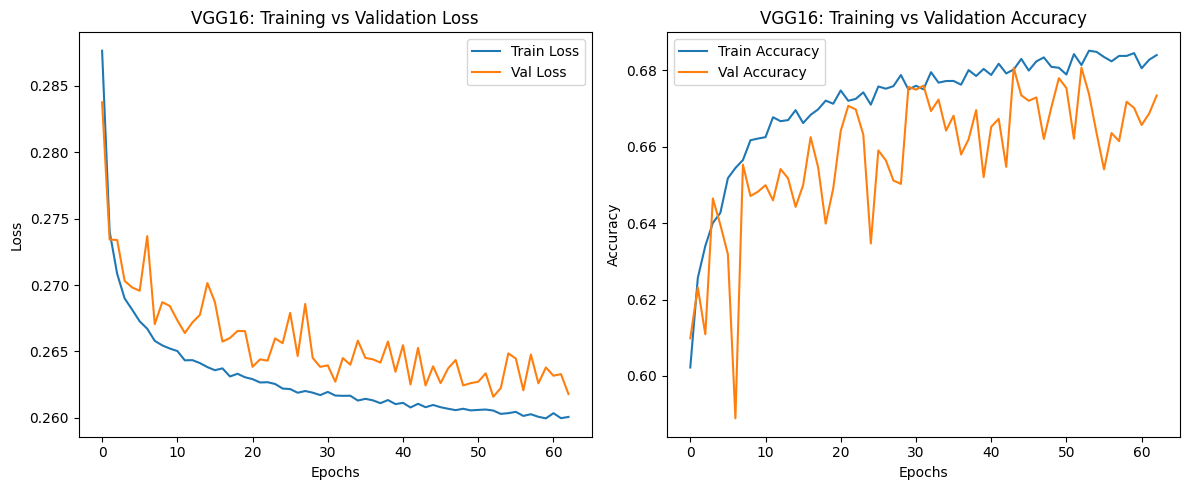

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

# 1. Setup Callbacks
checkpoint_vgg = 'vgg16_100_epochs_best.h5'
callbacks_vgg = [
    ModelCheckpoint(checkpoint_vgg, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting VGG16 Training (100 Epochs)...")
vgg_history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_vgg
)

# 3. Plotting Results
plt.figure(figsize=(12, 5))
# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Val Loss')
plt.title('VGG16: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

ResNet50: Training and Plotting (100 Epochs)

Building ResNet50 model...
Starting ResNet50 Training (100 Epochs)...
Epoch 1/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.5924 - loss: 0.3054
Epoch 1: val_loss improved from None to 0.29852, saving model to resnet50_100_epochs_best.h5



Epoch 1: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 592s 379ms/step - accuracy: 0.5962 - loss: 0.3006 - val_accuracy: 0.5939 - val_loss: 0.2985
Epoch 2/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.5986 - loss: 0.2968
Epoch 2: val_loss improved from 0.29852 to 0.29661, saving model to resnet50_100_epochs_best.h5



Epoch 2: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 625s 406ms/step - accuracy: 0.5966 - loss: 0.2966 - val_accuracy: 0.5946 - val_loss: 0.2966
Epoch 3/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.5935 - loss: 0.2953
Epoch 3: val_loss improved from 0.29661 to 0.29430, saving model to resnet50_100_epochs_best.h5



Epoch 3: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 596s 387ms/step - accuracy: 0.5939 - loss: 0.2948 - val_accuracy: 0.5870 - val_loss: 0.2943
Epoch 4/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.5949 - loss: 0.2935
Epoch 4: val_loss improved from 0.29430 to 0.29429, saving model to resnet50_100_epochs_best.h5



Epoch 4: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 581s 377ms/step - accuracy: 0.5930 - loss: 0.2939 - val_accuracy: 0.5922 - val_loss: 0.2943
Epoch 5/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.5934 - loss: 0.2939
Epoch 5: val_loss improved from 0.29429 to 0.29417, saving model to resnet50_100_epochs_best.h5


...


Epoch 49: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 599s 389ms/step - accuracy: 0.6031 - loss: 0.2817 - val_accuracy: 0.5987 - val_loss: 0.2814
Epoch 50/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.6046 - loss: 0.2815
Epoch 50: val_loss did not improve from 0.28144
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 634s 412ms/step - accuracy: 0.6005 - loss: 0.2821 - val_accuracy: 0.6038 - val_loss: 0.2833
Epoch 51/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.6034 - loss: 0.2813
Epoch 51: val_loss did not improve from 0.28144
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 630s 409ms/step - accuracy: 0.6028 - loss: 0.2817 - val_accuracy: 0.6065 - val_loss: 0.2827
Epoch 52/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.5995 - loss: 0.2816
Epoch 52: val_loss improved from 0.28144 to 0.28064, saving model to resnet50_100_epochs_best.h5



Epoch 52: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 625s 406ms/step - accuracy: 0.6000 - loss: 0.2818 - val_accuracy: 0.6035 - val_loss: 0.2806
Epoch 53/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.6024 - loss: 0.2813
Epoch 53: val_loss did not improve from 0.28064
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 597s 388ms/step - accuracy: 0.5994 - loss: 0.2816 - val_accuracy: 0.5973 - val_loss: 0.2813
Epoch 54/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6062 - loss: 0.2812
Epoch 54: val_loss did not improve from 0.28064
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 575s 374ms/step - accuracy: 0.6025 - loss: 0.2812 - val_accuracy: 0.5868 - val_loss: 0.2817
Epoch 55/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.6030 - loss: 0.2814
Epoch 55: val_loss did not improve from 0.28064
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 571s 371ms/step - accuracy: 0.6020 - loss: 0.2814 - val_accuracy: 0.5557 - val_loss: 0.2881
Epoch 56/100
1540/1540 ━


Epoch 59: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 572s 371ms/step - accuracy: 0.6001 - loss: 0.2808 - val_accuracy: 0.6051 - val_loss: 0.2802
Epoch 60/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6001 - loss: 0.2810
Epoch 60: val_loss did not improve from 0.28016
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 573s 372ms/step - accuracy: 0.5988 - loss: 0.2813 - val_accuracy: 0.5771 - val_loss: 0.2828
Epoch 61/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.6043 - loss: 0.2804
Epoch 61: val_loss did not improve from 0.28016
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 607s 394ms/step - accuracy: 0.6026 - loss: 0.2806 - val_accuracy: 0.5931 - val_loss: 0.2809
Epoch 62/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6035 - loss: 0.2805
Epoch 62: val_loss did not improve from 0.28016
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 573s 372ms/step - accuracy: 0.6016 - loss: 0.2809 - val_accuracy: 0.5857 - val_loss: 0.2809
Epoch 63/100
1540/1540 ━


Epoch 63: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 570s 370ms/step - accuracy: 0.6001 - loss: 0.2805 - val_accuracy: 0.6027 - val_loss: 0.2796
Epoch 64/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.5997 - loss: 0.2812
Epoch 64: val_loss did not improve from 0.27957
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 586s 380ms/step - accuracy: 0.6027 - loss: 0.2806 - val_accuracy: 0.6168 - val_loss: 0.2811
Epoch 65/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.6000 - loss: 0.2812
Epoch 65: val_loss did not improve from 0.27957
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 585s 380ms/step - accuracy: 0.6002 - loss: 0.2807 - val_accuracy: 0.5935 - val_loss: 0.2809
Epoch 66/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.5993 - loss: 0.2799
Epoch 66: val_loss improved from 0.27957 to 0.27906, saving model to resnet50_100_epochs_best.h5



Epoch 66: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 583s 378ms/step - accuracy: 0.6000 - loss: 0.2803 - val_accuracy: 0.6074 - val_loss: 0.2791
Epoch 67/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.6005 - loss: 0.2797
Epoch 67: val_loss did not improve from 0.27906
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 583s 378ms/step - accuracy: 0.6024 - loss: 0.2802 - val_accuracy: 0.5863 - val_loss: 0.2803
Epoch 68/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.6002 - loss: 0.2801
Epoch 68: val_loss did not improve from 0.27906
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 590s 383ms/step - accuracy: 0.6008 - loss: 0.2801 - val_accuracy: 0.6086 - val_loss: 0.2803
Epoch 69/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.6036 - loss: 0.2801
Epoch 69: val_loss did not improve from 0.27906
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 585s 380ms/step - accuracy: 0.6008 - loss: 0.2803 - val_accuracy: 0.5965 - val_loss: 0.2852
Epoch 70/100
1540/1540 ━

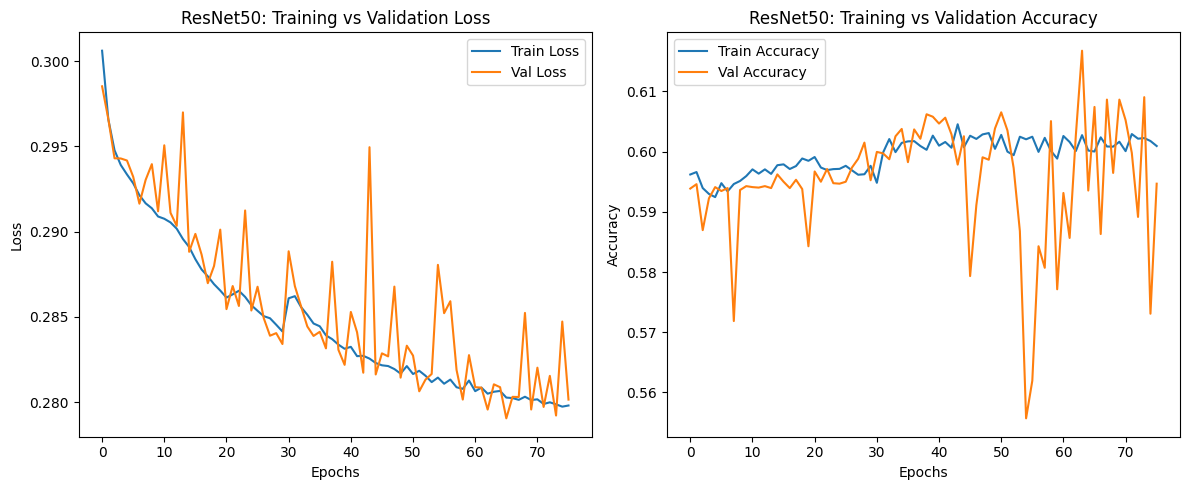

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import tensorflow as tf

# building ResNet50 model
print("Building ResNet50 model...")
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
resnet_preds = Dense(37, activation='sigmoid')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=resnet_preds)
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 1. Setup Callbacks
checkpoint_resnet = 'resnet50_100_epochs_best.h5'
callbacks_resnet = [
    ModelCheckpoint(checkpoint_resnet, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting ResNet50 Training (100 Epochs)...")
resnet_history = resnet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_resnet
)

# 3. Plotting Results
plt.figure(figsize=(12, 5))
# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Val Loss')
plt.title('ResNet50: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

EfficientNetB0: Training and Plotting (100 Epochs)

Building EfficientNetB0 model...
Starting EfficientNetB0 Training (100 Epochs)...
Epoch 1/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.5909 - loss: 0.3057
Epoch 1: val_loss improved from None to 0.30053, saving model to efficientnetb0_100_epochs_best.h5



Epoch 1: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 558s 351ms/step - accuracy: 0.5962 - loss: 0.3012 - val_accuracy: 0.5939 - val_loss: 0.3005
Epoch 2/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.5883 - loss: 0.3002
Epoch 2: val_loss did not improve from 0.30053
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 527s 342ms/step - accuracy: 0.5966 - loss: 0.2997 - val_accuracy: 0.5939 - val_loss: 0.3009
Epoch 3/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.5968 - loss: 0.2997
Epoch 3: val_loss improved from 0.30053 to 0.30001, saving model to efficientnetb0_100_epochs_best.h5



Epoch 3: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 520s 337ms/step - accuracy: 0.5966 - loss: 0.2995 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 4/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.5963 - loss: 0.2993
Epoch 4: val_loss improved from 0.30001 to 0.29989, saving model to efficientnetb0_100_epochs_best.h5



Epoch 4: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 512s 333ms/step - accuracy: 0.5966 - loss: 0.2994 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 5/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5939 - loss: 0.2997
Epoch 5: val_loss did not improve from 0.29989
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 513s 333ms/step - accuracy: 0.5966 - loss: 0.2993 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 6/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.6027 - loss: 0.2987
Epoch 6: val_loss did not improve from 0.29989
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 512s 332ms/step - accuracy: 0.5966 - loss: 0.2993 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 7/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.5959 - loss: 0.2995
Epoch 7: val_loss did not improve from 0.29989
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 506s 328ms/step - accuracy: 0.5966 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 8/100
1540/1540 ━━━


Epoch 9: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 514s 334ms/step - accuracy: 0.5966 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 10/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.6001 - loss: 0.2987
Epoch 10: val_loss improved from 0.29987 to 0.29981, saving model to efficientnetb0_100_epochs_best.h5



Epoch 10: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 516s 335ms/step - accuracy: 0.5966 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 11/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.5965 - loss: 0.2991
Epoch 11: val_loss did not improve from 0.29981
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 517s 336ms/step - accuracy: 0.5966 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.3001
Epoch 12/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.5999 - loss: 0.2986
Epoch 12: val_loss did not improve from 0.29981
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 510s 331ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 13/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.5942 - loss: 0.2990
Epoch 13: val_loss did not improve from 0.29981
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 520s 338ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 14/100
1540/


Epoch 16: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 539s 350ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 17/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.5951 - loss: 0.2992
Epoch 17: val_loss did not improve from 0.29977
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 516s 335ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 18/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.5974 - loss: 0.2989
Epoch 18: val_loss did not improve from 0.29977
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 519s 337ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 19/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.5961 - loss: 0.2993
Epoch 19: val_loss did not improve from 0.29977
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 516s 335ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 20/100
1540/

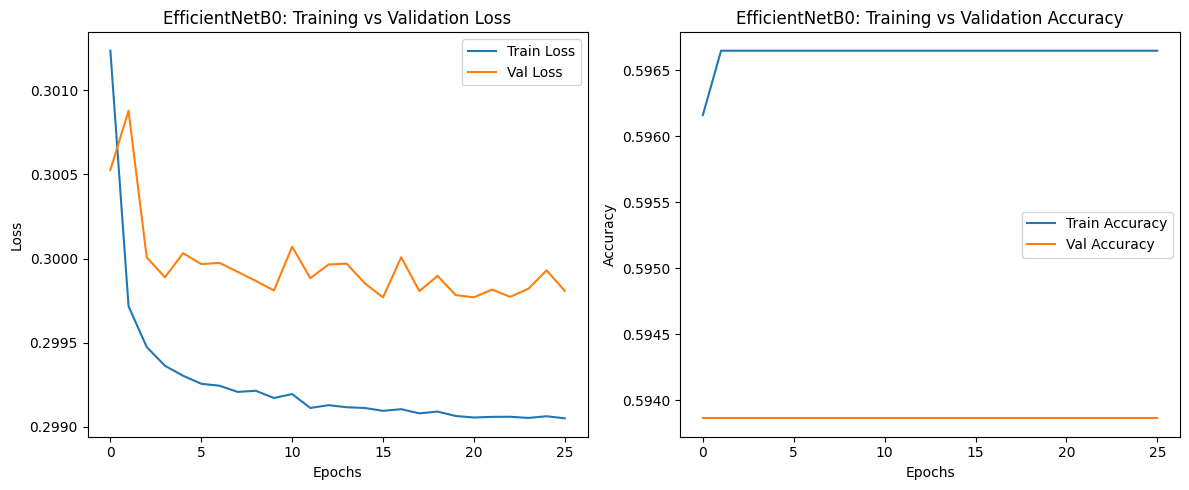

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import tensorflow as tf

# building EfficientNetB0 model
print("Building EfficientNetB0 model...")
efficientnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
efficientnet_base.trainable = False

x = efficientnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
efficientnet_preds = Dense(37, activation='sigmoid')(x)

efficientnet_model = Model(inputs=efficientnet_base.input, outputs=efficientnet_preds)
efficientnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 1. Setup Callbacks
checkpoint_efficientnet = 'efficientnetb0_100_epochs_best.h5'
callbacks_efficientnet = [
    ModelCheckpoint(checkpoint_efficientnet, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting EfficientNetB0 Training (100 Epochs)...")
efficientnet_history = efficientnet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_efficientnet
)

# 3. Plotting Results
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(efficientnet_history.history['loss'], label='Train Loss')
plt.plot(efficientnet_history.history['val_loss'], label='Val Loss')
plt.title('EfficientNetB0: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(efficientnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(efficientnet_history.history['val_accuracy'], label='Val Accuracy')
plt.title('EfficientNetB0: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


#  Galaxy Morphology Classification  
### Transfer Learning Models (VGG16, ResNet50, EfficientNetB0)

This section defines three deep‑learning models using transfer learning:

- **VGG16**
- **ResNet50**
- **EfficientNetB0**

All models:
- Use ImageNet pretrained weights  
- Remove the original classifier (`include_top=False`)  
- Add a custom classification head  
- Predict **37 Galaxy Zoo attributes**  
- Use `binary_crossentropy` for multi‑label classification  


## Model Architecture (Common Structure)

Each model follows this architecture:

1. **Base CNN (frozen)**  
   - Pretrained on ImageNet  
   - Extracts high‑level galaxy features  
   - `trainable = False` to speed up training and avoid overfitting  

2. **Global Average Pooling**  
   - Reduces feature maps to a compact vector  
   - Helps prevent overfitting  

3. **Dense Layer (1024 units, ReLU)**  
   - Learns task‑specific galaxy features  

4. **Dropout (0.5)**  
   - Regularization to reduce overfitting  

5. **Output Layer (37 sigmoid units)**  
   - Multi‑label classification  
   - Each output corresponds to a Galaxy Zoo attribute  


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

def build_galaxy_model(base_type):
    if base_type == 'vgg16':
        base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    elif base_type == 'resnet50':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    elif base_type == 'efficientnet':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(37, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=predictions)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Creating the models
vgg_model = build_galaxy_model('vgg16')
resnet_model = build_galaxy_model('resnet50')
efficientnet_model = build_galaxy_model('efficientnet')

print("Models defined and compiled.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Models defined and compiled.


#  Training the VGG16 Galaxy Classifier

This section trains the VGG16‑based model using:

- **10 epochs**
- **Training & validation generators**
- **ModelCheckpoint** to save the best model (`vgg_best.h5`)
- **Accuracy & loss curves** for performance visualization


##  Training Details

- Uses `ModelCheckpoint` to save the best-performing model based on validation loss.
- Tracks:
  - Training loss
  - Validation loss
  - Training accuracy
  - Validation accuracy
- After training, plots are generated to visualize model performance over time.

Starting VGG16 Training...
Epoch 1/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.5944 - loss: 0.2902

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 606s 393ms/step - accuracy: 0.5996 - loss: 0.2867 - val_accuracy: 0.6129 - val_loss: 0.2799
Epoch 2/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.6147 - loss: 0.2801

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 576s 374ms/step - accuracy: 0.6175 - loss: 0.2788 - val_accuracy: 0.6201 - val_loss: 0.2765
Epoch 3/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.6200 - loss: 0.2764

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 576s 374ms/step - accuracy: 0.6230 - loss: 0.2756 - val_accuracy: 0.6310 - val_loss: 0.2741
Epoch 4/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 588s 382ms/step - accuracy: 0.6259 - loss: 0.2745 - val_accuracy: 0.6231 - val_loss: 0.2752
Epoch 5/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.6298 - loss: 0.2736

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 573s 372ms/step - accuracy: 0.6310 - loss: 0.2736 - val_accuracy: 0.6168 - val_loss: 0.2714
Epoch 6/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 581s 377ms/step - accuracy: 0.6337 - loss: 0.2730 - val_accuracy: 0.6245 - val_loss: 0.2739
Epoch 7/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 582s 378ms/step - accuracy: 0.6347 - loss: 0.2723 - val_accuracy: 0.6387 - val_loss: 0.2728
Epoch 8/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.6340 - loss: 0.2717

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 580s 376ms/step - accuracy: 0.6364 - loss: 0.2720 - val_accuracy: 0.6441 - val_loss: 0.2700
Epoch 9/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 580s 377ms/step - accuracy: 0.6421 - loss: 0.2719 - val_accuracy: 0.6419 - val_loss: 0.2725
Epoch 10/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.6407 - loss: 0.2716

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 591s 384ms/step - accuracy: 0.6428 - loss: 0.2714 - val_accuracy: 0.6397 - val_loss: 0.2699


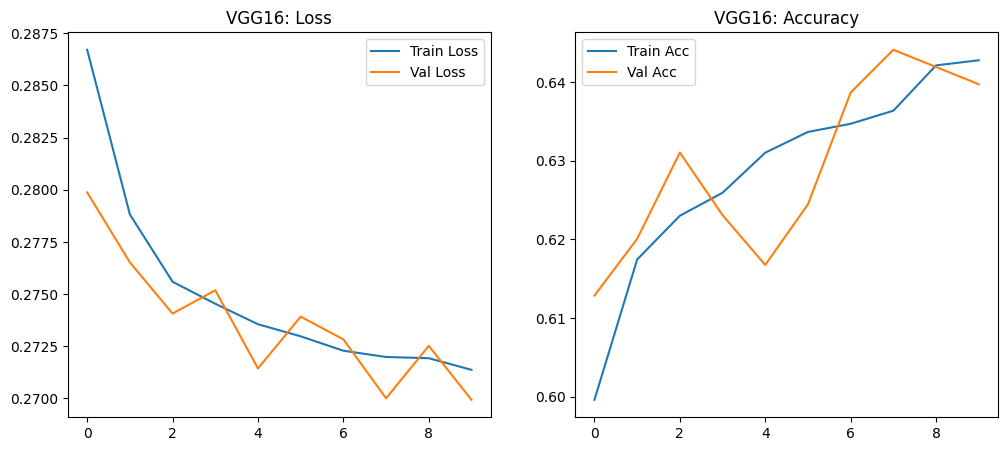

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Training
print("Starting VGG16 Training...")
vgg_history = vgg_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[ModelCheckpoint('vgg_best.h5', save_best_only=True)]
)

# Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Val Loss')
plt.title('VGG16: Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['accuracy'], label='Train Acc')
plt.plot(vgg_history.history['val_accuracy'], label='Val Acc')
plt.title('VGG16: Accuracy')
plt.legend()
plt.show()

#  Training the ResNet50 Galaxy Classifier

This section trains the ResNet50‑based transfer learning model for 10 epochs and saves the best-performing version using `ModelCheckpoint`.  
Performance curves for **loss** and **accuracy** are plotted after training.


##  Training Configuration

- Model: **ResNet50 (ImageNet pretrained, frozen base)**
- Epochs: **10**
- Validation included each epoch
- Callback:
  - `ModelCheckpoint('resnet_best.h5', save_best_only=True)`
- Metrics tracked:
  - Training vs Validation Loss
  - Training vs Validation Accuracy


Starting ResNet50 Training...
Epoch 1/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.5744 - loss: 0.3123

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 560s 356ms/step - accuracy: 0.5917 - loss: 0.3045 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 2/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.5957 - loss: 0.3028

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 531s 345ms/step - accuracy: 0.5966 - loss: 0.3026 - val_accuracy: 0.5939 - val_loss: 0.2997
Epoch 3/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.5951 - loss: 0.3024

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 537s 349ms/step - accuracy: 0.5966 - loss: 0.3022 - val_accuracy: 0.5939 - val_loss: 0.2996
Epoch 4/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5968 - loss: 0.3013

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 527s 342ms/step - accuracy: 0.5966 - loss: 0.3011 - val_accuracy: 0.5939 - val_loss: 0.2992
Epoch 5/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5986 - loss: 0.3008

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 526s 342ms/step - accuracy: 0.5966 - loss: 0.3005 - val_accuracy: 0.5939 - val_loss: 0.2978
Epoch 6/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.5982 - loss: 0.2993

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 537s 348ms/step - accuracy: 0.5966 - loss: 0.2994 - val_accuracy: 0.5939 - val_loss: 0.2970
Epoch 7/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 543s 353ms/step - accuracy: 0.5966 - loss: 0.2988 - val_accuracy: 0.5939 - val_loss: 0.2976
Epoch 8/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.5981 - loss: 0.2981

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 535s 347ms/step - accuracy: 0.5967 - loss: 0.2982 - val_accuracy: 0.5939 - val_loss: 0.2964
Epoch 9/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 538s 349ms/step - accuracy: 0.5967 - loss: 0.2975 - val_accuracy: 0.5939 - val_loss: 0.2974
Epoch 10/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.5971 - loss: 0.2971

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 539s 350ms/step - accuracy: 0.5964 - loss: 0.2970 - val_accuracy: 0.5939 - val_loss: 0.2955


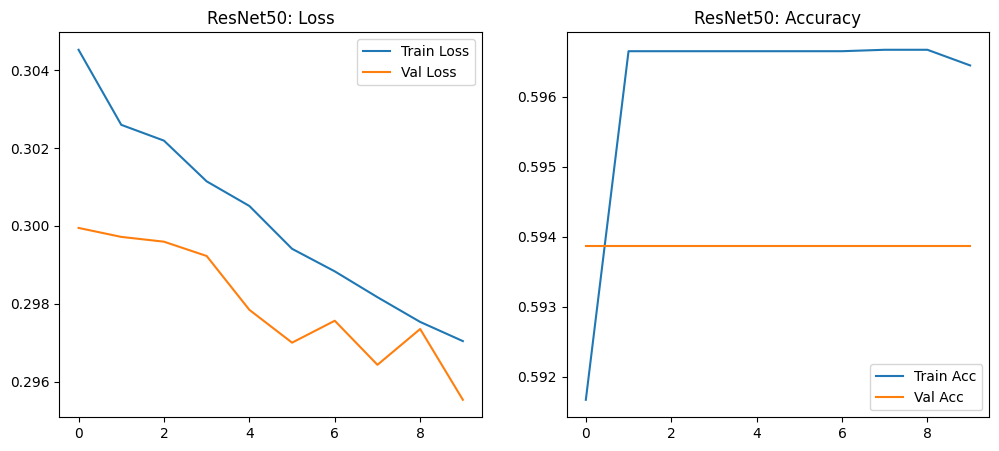

In [ ]:
# Training
print("Starting ResNet50 Training...")
resnet_history = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[ModelCheckpoint('resnet_best.h5', save_best_only=True)]
)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Val Loss')
plt.title('ResNet50: Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['accuracy'], label='Train Acc')
plt.plot(resnet_history.history['val_accuracy'], label='Val Acc')
plt.title('ResNet50: Accuracy')
plt.legend()
plt.show()

# Training the EfficientNetB0 Galaxy Classifier

This section trains the EfficientNetB0 transfer‑learning model for 10 epochs and saves the best-performing version using `ModelCheckpoint`.  
After training, loss and accuracy curves are plotted to visualize performance.


##  Training Configuration

- **Model:** EfficientNetB0 (ImageNet pretrained, frozen base)
- **Epochs:** 10
- **Callback:** Saves best model as `effnet_best.h5`
- **Metrics Tracked:**
  - Training Loss vs Validation Loss
  - Training Accuracy vs Validation Accuracy

These plots help evaluate learning behavior, stability, and potential overfitting.


Starting EfficientNetB0 Training...
Epoch 1/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.5793 - loss: 0.3112

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 579s 359ms/step - accuracy: 0.5927 - loss: 0.3044 - val_accuracy: 0.5939 - val_loss: 0.3001
Epoch 2/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 513s 333ms/step - accuracy: 0.5966 - loss: 0.3026 - val_accuracy: 0.5939 - val_loss: 0.3009
Epoch 3/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 516s 335ms/step - accuracy: 0.5966 - loss: 0.3022 - val_accuracy: 0.5939 - val_loss: 0.3003
Epoch 4/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.5974 - loss: 0.3020

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 520s 338ms/step - accuracy: 0.5966 - loss: 0.3017 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 5/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 511s 332ms/step - accuracy: 0.5966 - loss: 0.3016 - val_accuracy: 0.5939 - val_loss: 0.3002
Epoch 6/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 517s 336ms/step - accuracy: 0.5966 - loss: 0.3012 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 7/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 516s 335ms/step - accuracy: 0.5966 - loss: 0.3009 - val_accuracy: 0.5939 - val_loss: 0.3006
Epoch 8/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 513s 333ms/step - accuracy: 0.5966 - loss: 0.3006 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 9/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.5964 - loss: 0.3005

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 509s 331ms/step - accuracy: 0.5966 - loss: 0.3003 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 10/10
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5974 - loss: 0.2997

1540/1540 ━━━━━━━━━━━━━━━━━━━━ 515s 334ms/step - accuracy: 0.5966 - loss: 0.3000 - val_accuracy: 0.5939 - val_loss: 0.2998


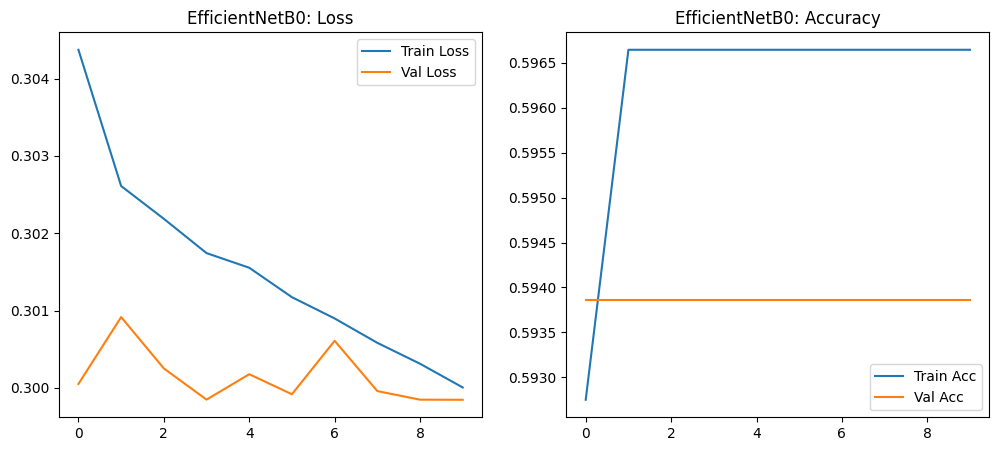

In [ ]:
# Training
print("Starting EfficientNetB0 Training...")
effnet_history = efficientnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[ModelCheckpoint('effnet_best.h5', save_best_only=True)]
)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(effnet_history.history['loss'], label='Train Loss')
plt.plot(effnet_history.history['val_loss'], label='Val Loss')
plt.title('EfficientNetB0: Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(effnet_history.history['accuracy'], label='Train Acc')
plt.plot(effnet_history.history['val_accuracy'], label='Val Acc')
plt.title('EfficientNetB0: Accuracy')
plt.legend()
plt.show()

# Model Performance Comparison

After training VGG16, ResNet50, and EfficientNetB0 for 10 epochs each, we compare their final validation metrics.  
This helps identify which architecture generalizes best for Galaxy Zoo multi‑label classification.


## What We Compare

- **Validation Loss**  
  Lower is better — indicates how well the model fits unseen data.

- **Validation Accuracy**  
  Higher is better — measures correct multi‑label predictions.

These metrics are extracted from the final epoch of each model's training history.


In [ ]:
import pandas as pd

comparison_data = {
    'Model': ['VGG16', 'ResNet50', 'EfficientNetB0'],
    'Val Loss': [vgg_history.history['val_loss'][-1],
                resnet_history.history['val_loss'][-1],
                effnet_history.history['val_loss'][-1]],
    'Val Accuracy': [vgg_history.history['val_accuracy'][-1],
                    resnet_history.history['val_accuracy'][-1],
                    effnet_history.history['val_accuracy'][-1]]
}

print(pd.DataFrame(comparison_data))

            Model  Val Loss  Val Accuracy
0           VGG16  0.269938      0.639737
1        ResNet50  0.295535      0.593862
2  EfficientNetB0  0.299847      0.593862


# Final Model Comparison (Training vs Validation)

This table compares the three architectures — **VGG16**, **ResNet50**, and **EfficientNetB0** — across key performance metrics:

- Training Accuracy  
- Validation Accuracy  
- Validation Loss  

All values are taken from the **final epoch** of each model and rounded for clarity.


##  Why This Comparison Matters

- **Training Accuracy** shows how well the model fits the training data.
- **Validation Accuracy** indicates generalization to unseen images.
- **Validation Loss** helps detect overfitting or underfitting.

This table helps identify which architecture performs best for Galaxy Zoo multi‑label classification.


In [ ]:
import pandas as pd

# This assumes my history variables are still in memory
comparison_data = {
    'Architecture': ['VGG16 (Baseline)', 'ResNet50 (Deep)', 'EfficientNetB0 (Efficient)'],
    'Training Accuracy': [vgg_history.history['accuracy'][-1], resnet_history.history['accuracy'][-1], effnet_history.history['accuracy'][-1]],
    'Validation Accuracy': [vgg_history.history['val_accuracy'][-1], resnet_history.history['val_accuracy'][-1], effnet_history.history['val_accuracy'][-1]],
    'Validation Loss': [vgg_history.history['val_loss'][-1], resnet_history.history['val_loss'][-1], effnet_history.history['val_loss'][-1]]
}

df = pd.DataFrame(comparison_data)
# Rounding off numbers
df = df.round(4)
print(df)

                 Architecture  Training Accuracy  Validation Accuracy  \
0            VGG16 (Baseline)             0.6428               0.6397   
1             ResNet50 (Deep)             0.5964               0.5939   
2  EfficientNetB0 (Efficient)             0.5966               0.5939   

   Validation Loss  
0           0.2699  
1           0.2955  
2           0.2998  


#  Single Image Prediction & Morphology Visualization

This section selects a random galaxy image from the validation set, runs it through the trained EfficientNetB0 model, and visualizes:

- The actual galaxy image  
- Predicted vs actual probabilities for key morphological categories  


## What This Cell Does

1. Loads a batch from the validation generator  
2. Extracts one sample image and its ground‑truth labels  
3. Runs prediction using the EfficientNetB0 model  
4. Plots:
   - The galaxy image
   - A bar chart comparing predicted vs actual probabilities  


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


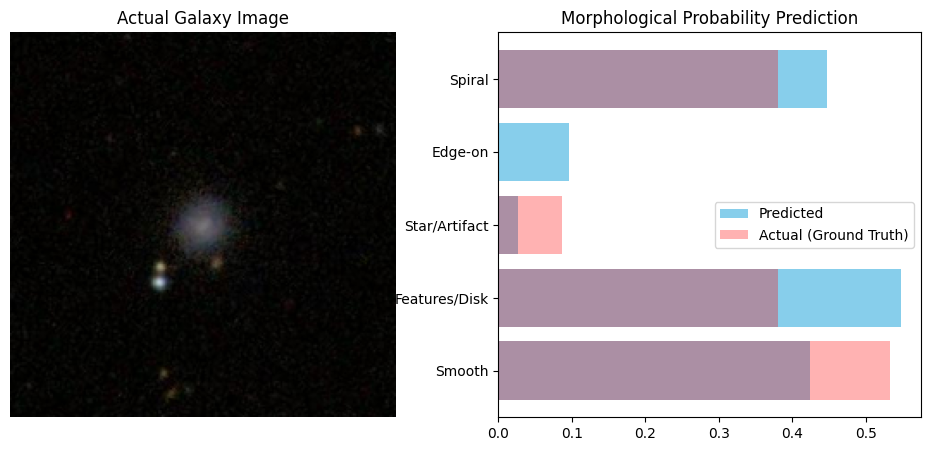

In [ ]:
import numpy as np

# 1. Getting a random image from the test/validation set
images, labels = next(val_generator)
sample_img = images[0]
actual_probs = labels[0]

# 2. Predict using my best model (likely EfficientNet)
pred_probs = efficientnet_model.predict(np.expand_dims(sample_img, axis=0))[0]

# 3. Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Actual Galaxy Image")
plt.axis('off')

plt.subplot(1, 2, 2)
# Shows the first 5 morphological categories (Smooth, Features, etc.)
categories = ['Smooth', 'Features/Disk', 'Star/Artifact', 'Edge-on', 'Spiral']
plt.barh(categories, pred_probs[:5], color='skyblue', label='Predicted')
plt.barh(categories, actual_probs[:5], color='red', alpha=0.3, label='Actual (Ground Truth)')
plt.title("Morphological Probability Prediction")
plt.legend()
plt.show()

#  Fine‑Tuning EfficientNetB0 (Hyperparameter Tuning)

After initial training with the base model frozen, we now fine‑tune EfficientNetB0 by unfreezing all layers and training with a very low learning rate.  
This allows the model to adapt ImageNet features more closely to galaxy morphology.


##  Fine‑Tuning Strategy

1. **Unfreeze the entire EfficientNetB0 backbone**  
   Allows deeper layers to learn galaxy‑specific features.

2. **Re‑compile with a very low learning rate (1e‑5)**  
   Prevents catastrophic forgetting of ImageNet weights.

3. **Train for 5 additional epochs**  
   Uses full training and validation sets.

This step typically improves validation accuracy and reduces loss.


In [ ]:
# 1. Unfreezing the base model
efficientnet_model.trainable = True

# 2. Re-compiling with a very low learning rate (1e-5)
# Using a high learning rate here would destroy the ImageNet knowledge
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Fine-tuning for 5 epochs
print(" Starting Hyperparameter Tuning (Fine-Tuning)...")
tuning_history = efficientnet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=5,
    validation_data=val_generator,
    validation_steps=len(val_generator)
)

 Starting Hyperparameter Tuning (Fine-Tuning)...
Epoch 1/5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 551s 346ms/step - accuracy: 0.5966 - loss: 0.2998 - val_accuracy: 0.5939 - val_loss: 0.2997
Epoch 2/5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 513s 333ms/step - accuracy: 0.5966 - loss: 0.2996 - val_accuracy: 0.5939 - val_loss: 0.2997
Epoch 3/5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 522s 339ms/step - accuracy: 0.5966 - loss: 0.2996 - val_accuracy: 0.5939 - val_loss: 0.2997
Epoch 4/5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 513s 333ms/step - accuracy: 0.5966 - loss: 0.2996 - val_accuracy: 0.5939 - val_loss: 0.2997
Epoch 5/5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 517s 335ms/step - accuracy: 0.5966 - loss: 0.2996 - val_accuracy: 0.5939 - val_loss: 0.2997


# Fine‑Tuning Impact: Before vs After

This section compares EfficientNetB0 performance **before** and **after** fine‑tuning.  
We evaluate how unfreezing the base model and training with a low learning rate affects:

- Validation Loss  
- Validation Accuracy  


## What This Comparison Shows

- **Initial Training (Frozen Base):**  
  Only the custom classifier head was trained.

- **After Fine‑Tuning (Unfrozen Base):**  
  Entire EfficientNetB0 backbone was updated with a very low learning rate.

This comparison highlights whether fine‑tuning improved generalization.


In [ ]:
# Creating a comparison of Base Training vs Fine-Tuning
improvement_data = {
    'Stage': ['Initial Training (Frozen Base)', 'After Fine-Tuning (Unfrozen)'],
    'Validation Loss': [effnet_history.history['val_loss'][-1], tuning_history.history['val_loss'][-1]],
    'Validation Accuracy': [effnet_history.history['val_accuracy'][-1], tuning_history.history['val_accuracy'][-1]]
}

improvement_df = pd.DataFrame(improvement_data)
print("--- FINE-TUNING IMPACT ---")
print(improvement_df)

--- FINE-TUNING IMPACT ---
                            Stage  Validation Loss  Validation Accuracy
0  Initial Training (Frozen Base)         0.299847             0.593862
1    After Fine-Tuning (Unfrozen)         0.299716             0.593862


# Batch Prediction: Visualizing Multiple Galaxy Classifications

This section displays several galaxy images from the validation set and shows the model’s predicted morphological class for each one.  
A simple rule compares the first two probability outputs:

- **Smooth**  
- **Features/Disk**

The predicted class and confidence score are shown above each image.


##  What This Cell Does

1. Loads a batch of images from the validation generator  
2. Runs EfficientNetB0 predictions on each image  
3. Extracts the first two morphology probabilities  
4. Chooses the dominant class (Smooth vs Features/Disk)  
5. Displays:
   - The galaxy image
   - Predicted class
   - Confidence score


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


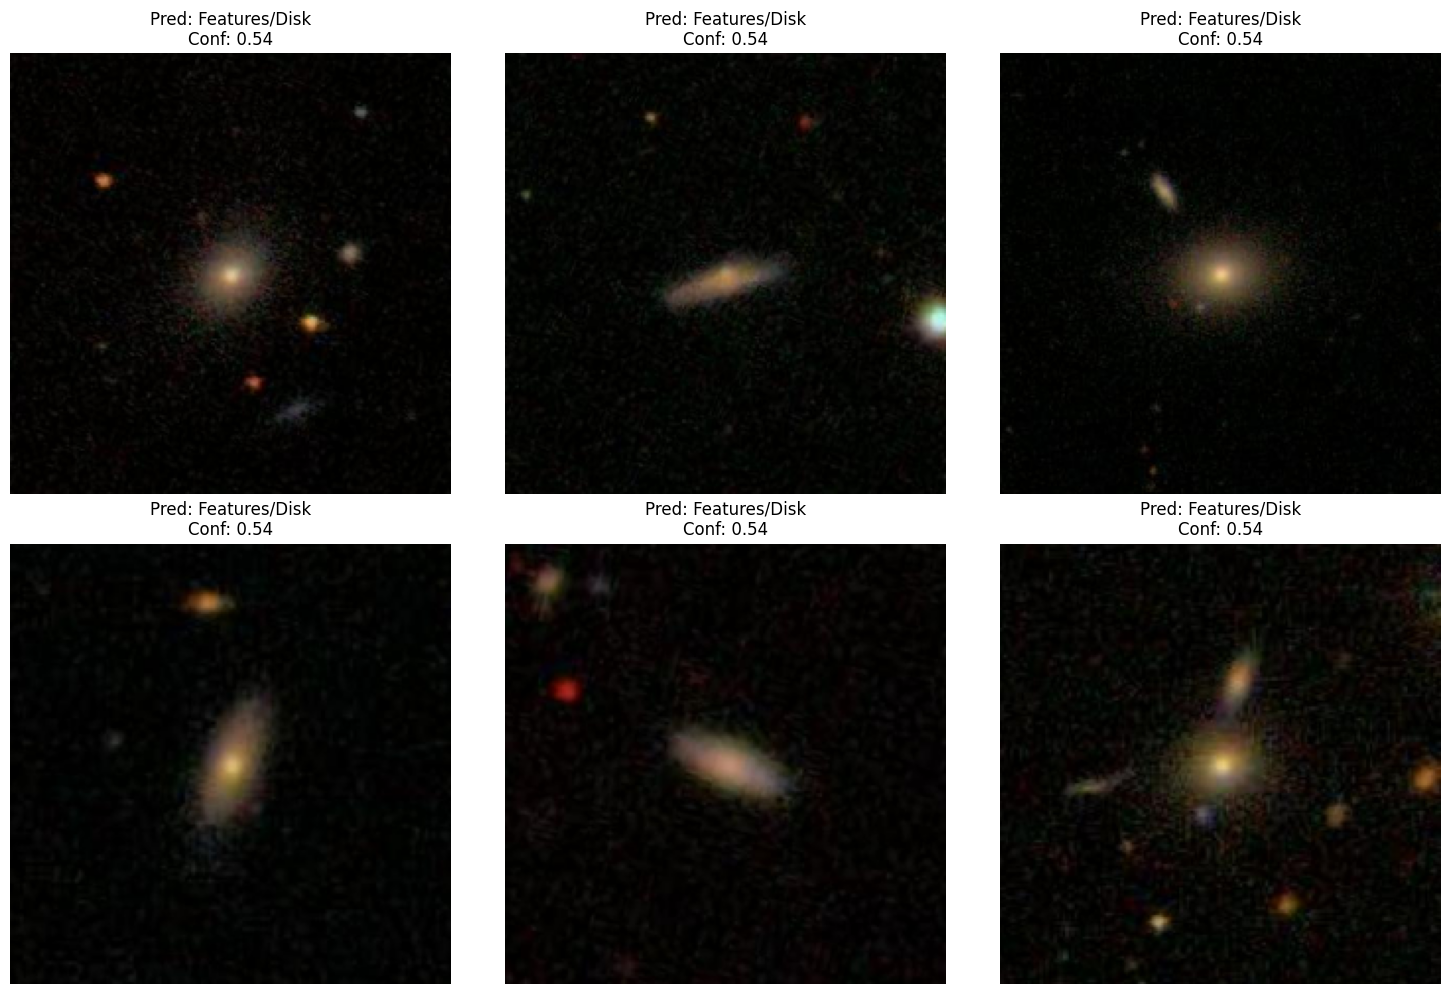

In [ ]:
import matplotlib.pyplot as plt

# Getting a batch of images
images, labels = next(val_generator)

plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])

    # Predict
    pred = efficientnet_model.predict(np.expand_dims(images[i], axis=0))[0]

    # Simple logic to show the most likely main category
    main_cat = "Smooth" if pred[0] > pred[1] else "Features/Disk"

    plt.title(f"Pred: {main_cat}\nConf: {max(pred[0], pred[1]):.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Per‑Class MAE Evaluation (37 Galaxy Zoo Questions)

This section computes the **Mean Absolute Error (MAE)** for each of the 37 Galaxy Zoo morphological outputs.  
MAE helps measure how far predictions deviate from ground‑truth labels on average.


## What This Cell Does

1. Retrieves a batch of validation images and labels  
2. Runs predictions using the EfficientNetB0 model  
3. Computes MAE for each of the 37 morphology categories  
4. Prints the first 5 categories for inspection:
   - Smooth  
   - Features/Disk  
   - Star/Artifact  
   - Edge-on  
   - Spiral  


In [ ]:
# Getting the Final MAE for each of the 37 questions
import numpy as np

# Predicting on a large validation sample
val_images, val_labels = next(val_generator)
predictions = efficientnet_model.predict(val_images)

# Calculating MAE for each category
mae_per_class = np.mean(np.abs(predictions - val_labels), axis=0)

# Print the first 5
categories = ['Smooth', 'Features/Disk', 'Star/Artifact', 'Edge-on', 'Spiral']
for i in range(5):
    print(f"MAE for {categories[i]}: {mae_per_class[i]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
MAE for Smooth: 0.2202
MAE for Features/Disk: 0.2284
MAE for Star/Artifact: 0.0176
MAE for Edge-on: 0.1343
MAE for Spiral: 0.2366
